# **Latin Morphological Analyser**

Dataset used:  
https://github.com/syntacticus/syntacticus-treebank-data  
https://dev.syntacticus.org/development-guide/#lemma-part-of-speech-and-morphology


## **Set Up Environment**

In [ ]:
import os

### Install Latin BERT

Download the pre-trained Latin BERT model from the GitHub repository and define the path for the model to be used for fine-tuning.

In [ ]:
# clone latin bert repo
!git clone https://github.com/dbamman/latin-bert.git
%cd latin-bert

fatal: destination path 'latin-bert' already exists and is not an empty directory.
/content/latin-bert


In [ ]:
# Download pre-trained BERT model for Latin
!./scripts/download.sh

--2026-03-18 17:49:19--  https://drive.usercontent.google.com/download?export=download&id=1Te_14UB-DZ8wYPhHGyDg7LadDTjNzpti&confirm=t&uuid=f78c0c66-c9eb-46d6-be84-2886f66527fa
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.69.132, 2a00:1450:4013:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448020480 (427M) [application/octet-stream]
Saving to: ‘latin_bert.tar’

latin_bert.tar      100%[===================>] 427.27M  23.0MB/s    in 8.0s    

2026-03-18 17:49:29 (53.5 MB/s) - ‘latin_bert.tar’ saved [448020480/448020480]



In [ ]:
!ls -lah models/latin_bert | head

total 428M
drwxrwxr-x 2 1001 1001 4.0K Sep  4  2020 .
drwxr-xr-x 4 root root 4.0K Mar 18 17:49 ..
-rw-rw-r-- 1 1001 1001  503 Sep  4  2020 config.json
-rw-rw-r-- 1 1001 1001 428M Sep  4  2020 pytorch_model.bin
-rw-rw-r-- 1 1001 1001 217K Sep  4  2020 vocab.txt


In [ ]:
%cd ..

/content


In [ ]:
MODEL_PATH = os.path.join("latin-bert", "models", "latin_bert")

### Import Dependencies

1. Import all required libraries.
2. Mount Google Drive for storage access.
3. Setup HuggingFace access through token.
4. Define available device to be used.

In [ ]:
import sys
from dataclasses import dataclass, field
from typing import Optional, Union
import xml.etree.ElementTree as ET
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import transformers
from transformers import AutoTokenizer, AutoModel, PreTrainedModel, PreTrainedConfig, PreTrainedTokenizerBase, TrainingArguments, Trainer
from transformers.modeling_outputs import TokenClassifierOutput
from datasets import Dataset
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


## **Prepare Data**

### Load Dataset

Parse the XML file into sentences containing tokens.

In [ ]:
DATA_PATH = '/content/drive/MyDrive/FYP/latin-nt.xml'

In [ ]:
# define token and sentence classes

@dataclass
class Token:
  id: str
  form: Optional[str]
  lemma: Optional[str]
  pos: Optional[str]
  morphology: Optional[str]
  head_id: Optional[str]
  relation: Optional[str]

@dataclass
class Sentence:
  id: str
  tokens: list[Token] = field(default_factory=list)


In [ ]:
# parses all sentences in xml file, returns a list containing the sentences

def parse_proiel_xml(filepath: str) -> list[Sentence]:
  tree = ET.parse(filepath)
  root = tree.getroot()
  sentences = []

  for sentence_el in root.iter("sentence"):
    sent = Sentence(id=sentence_el.get("id"))
    for token_el in sentence_el.findall("token"):
      # Skip empty/trace tokens (no 'form')
      if token_el.get("form") is None:
        continue
      sent.tokens.append(Token(
          id=token_el.get("id"),
          form=token_el.get("form"),
          lemma=token_el.get("lemma"),
          pos=token_el.get("part-of-speech"),
          morphology=token_el.get("morphology"),
          head_id=token_el.get("head-id"),
          relation=token_el.get("relation"),
      ))
    if sent.tokens:
      sentences.append(sent)

  return sentences


In [ ]:
# load all sentences
sentences = parse_proiel_xml(DATA_PATH)
print(f"Loaded {len(sentences)} sentences")

Loaded 11851 sentences


In [ ]:
sentences[0]

Sentence(id='12667', tokens=[Token(id='250021', form='liber', lemma='liber', pos='Nb', morphology='-s---mn--i', head_id='851355', relation='xobj'), Token(id='250022', form='generationis', lemma='generatio', pos='Nb', morphology='-s---fg--i', head_id='250021', relation='atr'), Token(id='250023', form='Iesu', lemma='Iesus', pos='Ne', morphology='-s---mg--i', head_id='250022', relation='atr'), Token(id='250024', form='Christi', lemma='Christus', pos='Ne', morphology='-s---mg--i', head_id='250023', relation='apos'), Token(id='250025', form='filii', lemma='filius', pos='Nb', morphology='-s---mg--i', head_id='250023', relation='apos'), Token(id='250026', form='David', lemma='David', pos='Ne', morphology='---------n', head_id='250025', relation='atr'), Token(id='250027', form='filii', lemma='filius', pos='Nb', morphology='-s---mg--i', head_id='250025', relation='apos'), Token(id='250028', form='Abraham', lemma='Abraham', pos='Ne', morphology='---------n', head_id='250027', relation='atr')])

### Extract Labels from Data

**PROIEL morphology string decoder**  

The PROIEL `morphology` field is a 10-char positional string.  
Each character encodes one feature. Unused positions are "-".  
Reference: https://dev.syntacticus.org/development-guide/#lemma-part-of-speech-and-morphology

<br>

The final 2 characters ("strength" and "inflection") will be ignored.
*   no records contain "strength" info
*   "non-inflecting" tokens contain no other morphological information



In [ ]:
# mapping of the meaning of each char in the morphology string
MORPH_POSITIONS = {
    0: ("person", {"1": "1", "2": "2", "3": "3", "x": "Unc", "-": "None"}),
    1: ("number", {"s": "Sing", "p": "Plur", "d": "Dual", "x": "Unc", "-": "None"}),
    2: ("tense", {"p": "Pres", "i": "Imp", "r": "Perf", "l": "Plup", "f": "Fut",
                  "t": "FutPerf", "u": "Past", "s": "Res", "a": "Aorist", "x": "Unc", "-": "None"}), # "s" = "resultative"
    3: ("mood", {"i": "Ind", "s": "Sub", "m": "Imp", "o": "Opt", "n": "Inf", "p": "Part",
                 "d": "Ger", "g": "Gdv", "u": "Sup", "x": "Unc", "y": "FinUnsp", "e": "IndOrSub",
                 "f": "IndOrImp", "h": "SubOrImp", "t": "Fin", "-":"None"}),
    4: ("voice", {"a": "Act", "p": "Pass", "m": "Mid", "e": "MidOrPass", "x": "Unsp", "-": "None"}),
    5: ("gender", {"m": "Masc", "f": "Fem", "n": "Neut",
                   "p": "MascFem", "o": "MascNeut", "r": "FemNeut",
                   "q": "MascFemNeut", "x": "Unc", "-": "None"}),
    6: ("case", {"n": "Nom", "g": "Gen", "d": "Dat", "a": "Acc",
                 "b": "Abl", "v": "Voc", "l": "Loc", "o": "Obl",
                 "c": "GenDat", "e": "AccDat", "i": "Instr", "x": "Unc",
                 "z": "No", "-": "None"}),
    7: ("degree", {"p": "Pos", "c": "Comp", "s": "Sup", "x": "Unc", "z": "No", "-": "None"}),
    # 8: ("strength", {"w": "Weak", "s": "Strong", "t": "WkOrSt"}), # "t": "weak or strong"
    # 9: ("inflection", {"n": "NonInf", "i": "Inf"})                # non-inflecting, inflecting
}

# the order in which each feature appears in the morphology string
FEATURE_ORDER = ["person", "number", "tense", "mood", "voice",  "gender", "case",  "degree"]

In [ ]:
def decode_morphology(morph_str: str) -> dict:
    """
    Decode a PROIEL morphology string into a named feature dict.
    e.g. "3s---mn-" -> {"person":"3", "number":"Sing", ..., "case":"Nom", ...}
    Returns "None" for any absent/inapplicable position.
    """
    result = {feat: "None" for _, (feat, _) in MORPH_POSITIONS.items()}
    if not morph_str:
        return result
    for pos, (feat, mapping) in MORPH_POSITIONS.items():
        if pos < len(morph_str):
            result[feat] = mapping.get(morph_str[pos], "None")
    return result

**POS -> feature compatibility matrix**

Maps each specific PROIEL POS code to its applicable features, defines which of the morphological features are applicable per POS.

Order matches `FEATURE_ORDER`: person, number, tense, mood, voice, gender, case, degree

In [ ]:
# TODO: FIX TRUTH VALUES, CURRENTLY NOT ALL CORRECT

#          per    num    tense  mood   voice  gender case   degree
POS_FEATURE_MASK = {
    "A-": [False, True,  False, False, False, True,  True,  True  ],  # adjective
    "C-": [False, False, False, False, False, False, False, False ],  # conjunction
    "Df": [False, False, False, False, False, False, False, True  ],  # adverb
    "Dq": [False, False, False, False, False, False, False, False ],  # relative adverb
    "Du": [False, False, False, False, False, False, False, False ],  # interrogative adverb
    "F-": [False, False, False, False, False, False, False, False ],  # foreign word
    "G-": [False, False, False, False, False, False, False, False ],  # subjunction
    "I-": [False, False, False, False, False, False, False, False ],  # interjection
    "Ma": [False, True,  False, False, False, True,  True,  False ],  # cardinal numeral
    "Mo": [False, True,  False, False, False, True,  True,  False ],  # ordinal numeral
    "N-": [False, False, False, False, False, False, False, False ],  # infinitive marker
    "Nb": [False, True,  False, False, False, True,  True,  False ],  # common noun
    "Ne": [False, True,  False, False, False, True,  True,  False ],  # proper noun
    "Pc": [False, True,  False, False, False, True,  True,  False ],  # reciprocal pronoun
    "Pd": [False, True,  False, False, False, True,  True,  False ],  # demonstrative pronoun
    "Pi": [False, True,  False, False, False, True,  True,  False ],  # interrogative pronoun
    "Pk": [False, True,  False, False, False, True,  True,  False ],  # personal reflexive pronoun
    "Pp": [False, True,  False, False, False, True,  True,  False ],  # personal pronoun
    "Pr": [False, True,  False, False, False, True,  True,  False ],  # relative pronoun
    "Ps": [False, True,  False, False, False, True,  True,  False ],  # possessive pronoun
    "Pt": [False, True,  False, False, False, True,  True,  False ],  # possessive reflexive pronoun
    "Px": [False, True,  False, False, False, True,  True,  False ],  # indefinite pronoun
    "Py": [False, False, False, False, False, False, False, False ],  # quantifier
    "R-": [False, False, False, False, False, False, False, False ],  # preposition
    "S-": [False, False, False, False, False, False, False, False ],  # article
    "V-": [True,  True,  True,  True,  True,  False, False, False ],  # verb
    "X-": [False, False, False, False, False, False, False, False ]   # unassigned
}

**Build label vocabularies from data**

In [ ]:
def build_label_vocabs(sentences):
  """
  Scan all sentences and collect every observed value per feature.
  """
  vocabs = defaultdict(set)
  vocabs["pos"] = set()

  for sent in sentences:
    for tok in sent.tokens:
      if not tok.pos:
        continue
      vocabs["pos"].add(tok.pos)
      feats = decode_morphology(tok.morphology)
      for feat, val in feats.items():
        vocabs[feat].add(val)

  # Build label2id / id2label dicts; keep "None" last in each vocab
  label2id_all, id2label_all = {}, {}
  for feat, vals in vocabs.items():
    sorted_vals = sorted(v for v in vals if v != "None")
    if "None" in vals:
      sorted_vals.append("None")
    label2id_all[feat] = {v: i for i, v in enumerate(sorted_vals)}
    id2label_all[feat] = {i: v for v, i in label2id_all[feat].items()}

  return label2id_all, id2label_all

In [ ]:
# Build label vocabularies from data.
label2id_all, id2label_all = build_label_vocabs(sentences)

ALL_FEATS = ["pos"] + FEATURE_ORDER

# Quick summary
for feat in ALL_FEATS:
  print(f"{feat:10s} ({len(label2id_all[feat])} labels): {list(label2id_all[feat].keys())}")

pos        (23 labels): ['A-', 'C-', 'Df', 'Dq', 'Du', 'F-', 'G-', 'I-', 'Ma', 'Mo', 'Nb', 'Ne', 'Pc', 'Pd', 'Pi', 'Pk', 'Pp', 'Pr', 'Ps', 'Pt', 'Px', 'R-', 'V-']
person     (4 labels): ['1', '2', '3', 'None']
number     (3 labels): ['Plur', 'Sing', 'None']
tense      (7 labels): ['Fut', 'FutPerf', 'Imp', 'Perf', 'Plup', 'Pres', 'None']
mood       (9 labels): ['Gdv', 'Ger', 'Imp', 'Ind', 'Inf', 'Part', 'Sub', 'Sup', 'None']
voice      (3 labels): ['Act', 'Pass', 'None']
gender     (8 labels): ['Fem', 'FemNeut', 'Masc', 'MascFem', 'MascFemNeut', 'MascNeut', 'Neut', 'None']
case       (7 labels): ['Abl', 'Acc', 'Dat', 'Gen', 'Nom', 'Voc', 'None']
degree     (4 labels): ['Comp', 'Pos', 'Sup', 'None']


**Convert sentences to multi-label records**

In [ ]:
IGNORE_INDEX = -100

def to_multilabel_records(sentences, label2id_all):
    records = []
    for sent in sentences:
        tokens, pos_labels = [], []
        feat_labels = {feat: [] for feat in FEATURE_ORDER}
        valid = True

        for tok in sent.tokens:
            if not tok.pos or tok.pos not in label2id_all["pos"]:
                valid = False
                break
            tokens.append(tok.form.lower())
            pos_labels.append(label2id_all["pos"][tok.pos])

            feats = decode_morphology(tok.morphology)
            for feat in FEATURE_ORDER:
                feat_labels[feat].append(label2id_all[feat][feats[feat]])

        if valid and len(tokens) == len(pos_labels):
            record = {"tokens": tokens, "labels_pos": pos_labels}
            for feat in FEATURE_ORDER:
                record[f"labels_{feat}"] = feat_labels[feat]
            records.append(record)

    return records

In [ ]:
multilabel_records = to_multilabel_records(sentences, label2id_all)
print(f"Total records: {len(multilabel_records)}")

Total records: 11851


### Split into Train/Test/Validation Sets

In [ ]:
# 70% train, 15% test, 15% val
multi_dataset = Dataset.from_list(multilabel_records)
multi_dataset = multi_dataset.train_test_split(test_size=0.3, seed=42)
train_ds = multi_dataset["train"]
test_val = multi_dataset["test"].train_test_split(test_size=0.5, seed=42)
test_ds  = test_val["train"]
val_ds   = test_val["test"]

In [ ]:
train_ds[0]

{'tokens': ['domine', 'bonum', 'est', 'nos', 'hic', 'esse'],
 'labels_pos': [10, 0, 22, 16, 2, 22],
 'labels_person': [3, 3, 2, 0, 3, 3],
 'labels_number': [1, 1, 1, 0, 2, 2],
 'labels_tense': [6, 6, 5, 6, 6, 5],
 'labels_mood': [8, 8, 3, 8, 8, 4],
 'labels_voice': [2, 2, 0, 2, 2, 0],
 'labels_gender': [2, 6, 7, 2, 7, 7],
 'labels_case': [5, 4, 6, 1, 6, 6],
 'labels_degree': [3, 1, 3, 3, 3, 3]}

In [ ]:
print(f"{len(train_ds)} train | {len(val_ds)} val | {len(test_ds)} test")

8295 train | 1778 val | 1778 test


## **Tokenization**

### Load Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [ ]:
type(tokenizer)

transformers.models.bert.tokenization_bert.BertTokenizer

In [ ]:
# tokenize function
def tokenize_and_align_multilabels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128,
    )

    all_aligned = {feat: [] for feat in ALL_FEATS}

    for i in range(len(batch["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_wid = None
        per_feat = {feat: [] for feat in ALL_FEATS}

        for wid in word_ids:
            is_first = (wid is not None and wid != prev_wid)
            for feat in ALL_FEATS:
                word_labels = batch[f"labels_{feat}"][i]
                if wid is None:
                    per_feat[feat].append(IGNORE_INDEX)
                elif is_first:
                    per_feat[feat].append(word_labels[wid])
                else:
                    per_feat[feat].append(IGNORE_INDEX)
            prev_wid = wid

        for feat in ALL_FEATS:
            all_aligned[feat].append(per_feat[feat])

    for feat in ALL_FEATS:
        tokenized[f"labels_{feat}"] = all_aligned[feat]

    return tokenized

### Tokenize Dataset

In [ ]:
# Columns to drop — "tokens" (strings) and original word-level label lists
# The aligned labels_{feat} overwrite the word-level ones with the same key,
# but "tokens" has no counterpart to overwrite it, so it must be removed.
cols_to_remove = ["tokens"] + [f"labels_{feat}" for feat in ALL_FEATS]

In [ ]:
train_ds = train_ds.map(tokenize_and_align_multilabels, batched=True, remove_columns=cols_to_remove)
val_ds = val_ds.map(tokenize_and_align_multilabels,   batched=True, remove_columns=cols_to_remove)
test_ds = test_ds.map(tokenize_and_align_multilabels,  batched=True, remove_columns=cols_to_remove)

Map:   0%|          | 0/8295 [00:00<?, ? examples/s]

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

In [ ]:
# Verify only tensor-compatible columns remain
print(train_ds.column_names)
# Expected: ['input_ids', 'attention_mask', 'token_type_ids',
#            'labels_pos', 'labels_person', ..., 'labels_degree']

['labels_pos', 'labels_person', 'labels_number', 'labels_tense', 'labels_mood', 'labels_voice', 'labels_gender', 'labels_case', 'labels_degree', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
print(train_ds[0])

{'labels_pos': [-100, 10, 0, 22, 16, 2, 22, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100], 'labels_person': [-100, 3, 3, 2, 0, 3, 3, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -

## **Define Model**

**POS-feature compatibility mask tensor**

In [ ]:
def build_pos_mask_tensor(label2id_pos, device):
    """
    Build a (num_pos, num_features) bool tensor directly from POS_FEATURE_MASK.
    Any POS code not listed in POS_FEATURE_MASK gets all-False (no features).
    Unknown codes are reported so you can add them explicitly.
    """
    num_pos   = len(label2id_pos)
    num_feats = len(FEATURE_ORDER)
    mask      = torch.zeros(num_pos, num_feats, dtype=torch.bool)

    for pos_code, pos_idx in label2id_pos.items():
        if pos_code in POS_FEATURE_MASK:
            for fi, applicable in enumerate(POS_FEATURE_MASK[pos_code]):
                mask[pos_idx, fi] = applicable
        else:
            # Surface any unmapped codes immediately rather than silently
            # treating them as all-False
            print(f"WARNING: POS code '{pos_code}' not in POS_FEATURE_MASK "
                  f"— all features will be masked off for this tag. "
                  f"Add it explicitly.")

    return mask.to(device)

In [ ]:
pos_mask_tensor = build_pos_mask_tensor(label2id_all["pos"], device)

In [ ]:
# Sanity checks — print the mask for every code in your corpus
print(f"{'Code':<6} {'Features active':}")
for pos_code, pos_idx in sorted(label2id_all["pos"].items()):
    active = [f for fi, f in enumerate(FEATURE_ORDER)
              if pos_mask_tensor[pos_idx, fi].item()]
    print(f"  {pos_code:<6} {active if active else '—'}")

Code   Features active
  A-     ['number', 'gender', 'case', 'degree']
  C-     —
  Df     ['degree']
  Dq     —
  Du     —
  F-     —
  G-     —
  I-     —
  Ma     ['number', 'gender', 'case']
  Mo     ['number', 'gender', 'case']
  Nb     ['number', 'gender', 'case']
  Ne     ['number', 'gender', 'case']
  Pc     ['number', 'gender', 'case']
  Pd     ['number', 'gender', 'case']
  Pi     ['number', 'gender', 'case']
  Pk     ['number', 'gender', 'case']
  Pp     ['number', 'gender', 'case']
  Pr     ['number', 'gender', 'case']
  Ps     ['number', 'gender', 'case']
  Pt     ['number', 'gender', 'case']
  Px     ['number', 'gender', 'case']
  R-     —
  V-     ['person', 'number', 'tense', 'mood', 'voice']


**Multi-head model definition**

In [ ]:
class LatinMorphologicalAnalyserConfig(PreTrainedConfig):
  '''
  '''
  model_type = "latin_morphological_analyser"

  def __init__(self, bert_model_path="", num_labels_per_feat=None, pos_embed_dim=64, dropout=0.1, **kwargs):
    super().__init__(**kwargs)
    self.bert_model_path    = bert_model_path
    self.num_labels_per_feat = num_labels_per_feat or {}
    self.pos_embed_dim      = pos_embed_dim
    self.dropout            = dropout

In [ ]:
class POSConditionedHead(nn.Module):
    """
    A 2-layer classification head that concatenates the BERT token
    embedding with a soft POS context vector before classifying.
    """
    def __init__(self, bert_hidden, pos_embed_dim, num_labels, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bert_hidden + pos_embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, bert_repr, pos_context):
        # bert_repr  : (..., bert_hidden)
        # pos_context: (..., pos_embed_dim)
        return self.net(torch.cat([bert_repr, pos_context], dim=-1))

In [ ]:
class LatinMorphologicalAnalyser(PreTrainedModel):
  '''
  '''
  config_class = LatinMorphologicalAnalyserConfig

  def __init__(self, config, bert_model_path, label2id_all, id2label_all, pos_mask_tensor):
    super().__init__(config)

    self.bert           = AutoModel.from_pretrained(bert_model_path)
    hidden              = self.bert.config.hidden_size
    self.label2id_all   = label2id_all
    self.id2label_all   = id2label_all
    self.pos_mask       = pos_mask_tensor   # (num_pos, num_feats)
    self.feature_order  = FEATURE_ORDER

    num_pos        = config.num_labels_per_feat["pos"]
    pos_embed_dim  = config.pos_embed_dim
    dropout        = config.dropout

    # ── POS head (no POS conditioning — feeds raw BERT repr) ──────
    self.pos_dropout = nn.Dropout(dropout)
    self.pos_head    = nn.Linear(hidden, num_pos)

    # ── Soft POS conditioning embedding ───────────────────────────
    # pos_probs (batch, seq, num_pos) @ pos_embedding.weight (num_pos, dim)
    # → pos_context (batch, seq, dim)   [fully differentiable]
    self.pos_embedding = nn.Embedding(num_pos, pos_embed_dim)

    # ── One conditioned head per morphological feature ─────────────
    self.feature_heads = nn.ModuleDict({
        feat: POSConditionedHead(
            bert_hidden   = hidden,
            pos_embed_dim = pos_embed_dim,
            num_labels    = config.num_labels_per_feat[feat],
            dropout       = dropout,
        )
        for feat in FEATURE_ORDER
    })


  def forward(self, input_ids=None, attention_mask=None, labels_pos=None, labels_person=None, labels_number=None, labels_tense=None, labels_mood=None, labels_voice=None, labels_gender=None, labels_case=None, labels_degree=None, **kwargs):

    # ── 1. BERT ────────────────────────────────────────────────────
    bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    x = self.pos_dropout(bert_out.last_hidden_state)  # (B, T, H)

    # ── 2. POS classification ──────────────────────────────────────
    pos_logits = self.pos_head(x)                      # (B, T, num_pos)
    pos_probs  = torch.softmax(pos_logits, dim=-1)     # (B, T, num_pos)

    # ── 3. Soft POS context (differentiable weighted sum) ──────────
    pos_context = pos_probs @ self.pos_embedding.weight  # (B, T, pos_dim)

    # ── 4. Feature heads ───────────────────────────────────────────
    label_tensors = {
        "person": labels_person, "number": labels_number,
        "tense":  labels_tense,  "mood":   labels_mood,
        "voice":  labels_voice,  "gender": labels_gender,
        "case":   labels_case,   "degree": labels_degree,
    }
    feature_logits = {
        feat: head(x, pos_context)
        for feat, head in self.feature_heads.items()
    }   # each: (B, T, num_labels_for_feat)

    # ── 5. Loss ────────────────────────────────────────────────────
    loss = None
    if labels_pos is not None:
      import torch.nn.functional as F

      # POS loss — always computed for all valid tokens
      pos_loss = F.cross_entropy(
          pos_logits.view(-1, pos_logits.size(-1)),
          labels_pos.view(-1),
          ignore_index=IGNORE_INDEX,
      )
      loss = pos_loss

      for feat_idx, feat in enumerate(FEATURE_ORDER):
        feat_labels = label_tensors[feat]
        if feat_labels is None:
            continue

        # Build a boolean mask: which tokens have this feature applicable?
        #   - token must not be padding (labels_pos != IGNORE_INDEX)
        #   - token's TRUE POS must have this feature active
        valid      = labels_pos != IGNORE_INDEX          # (B, T)
        pos_clamp  = labels_pos.clone()
        pos_clamp[~valid] = 0                            # safe index
        applicable = self.pos_mask[pos_clamp, feat_idx]  # (B, T) bool
        applicable = applicable & valid

        if applicable.any():
          feat_loss = F.cross_entropy(
              feature_logits[feat][applicable],   # (N, num_labels)
              feat_labels[applicable],            # (N,)
              ignore_index=IGNORE_INDEX,
          )
          loss = loss + feat_loss

    # Return pos_logits as primary logits (Trainer compatibility).
    # Stash feature_logits in hidden_states for custom inference.
    return TokenClassifierOutput(
        loss=loss,
        logits=pos_logits,
        hidden_states=(feature_logits,),
    )

## **Train Model**

In [ ]:
# Define a path for a dummy file to satisfy transformers' internal checks
dummy_file_path = 'latin_morphological_analyser_model.py'

# Create the dummy file if it doesn't exist
if not os.path.exists(dummy_file_path):
    with open(dummy_file_path, 'w') as f:
        f.write("# Dummy file for __main__ module in Colab to satisfy transformers library checks\n")

sys.modules['__main__'].__file__ = dummy_file_path

### Load Model

In [ ]:
num_labels_per_feat = {feat: len(vocab) for feat, vocab in label2id_all.items()}

morph_config = LatinMorphologicalAnalyserConfig(
    bert_model_path    = MODEL_PATH,
    num_labels_per_feat = num_labels_per_feat,
    pos_embed_dim      = 64,
    dropout            = 0.1,
)

model_multi = LatinMorphologicalAnalyser(
    config          = morph_config,
    bert_model_path = MODEL_PATH,
    label2id_all    = label2id_all,
    id2label_all    = id2label_all,
    pos_mask_tensor = pos_mask_tensor,
).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: latin-bert/models/latin_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
total_params = sum(p.numel() for p in model_multi.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 113,045,252


### Define Custom Data Collator

In [ ]:
@dataclass
class MultiLabelDataCollator:
    tokenizer:           PreTrainedTokenizerBase
    padding:             Union[bool, str] = True
    max_length:          Optional[int]   = None
    label_pad_token_id:  int             = IGNORE_INDEX
    feat_names:          list            = None

    def __call__(self, features):
        label_keys = [f"labels_{f}" for f in self.feat_names]

        labels_dict = {k: [f[k] for f in features] for k in label_keys}
        stripped    = [{k: v for k, v in f.items()
                        if k not in label_keys} for f in features]

        batch   = self.tokenizer.pad(
            stripped, padding=self.padding,
            max_length=self.max_length, return_tensors="pt",
        )
        seq_len = batch["input_ids"].shape[1]

        for key, seqs in labels_dict.items():
            padded = [
                # Convert to list first — seq may be a tensor when
                # the dataset is in torch format (e.g. inside a DataLoader)
                list(seq) + [self.label_pad_token_id] * (seq_len - len(seq))
                for seq in seqs
            ]
            batch[key] = torch.tensor(padded, dtype=torch.long)

        return batch

In [ ]:
data_collator_multi = MultiLabelDataCollator(
    tokenizer  = tokenizer,
    feat_names = ALL_FEATS,
)

### Compute Metrics Function

POS accuracy shown during training

In [ ]:
def compute_metrics_pos(eval_pred):
    """
    Trainer passes EvalPrediction(predictions, label_ids).
    predictions will be pos_logits and label_ids will be labels_pos.
    Compute POS-level metrics for monitoring.
    """
    # If eval_pred.predictions is a tuple, take the first element (pos_logits)
    if isinstance(eval_pred.predictions, tuple):
        logits = eval_pred.predictions[0]
    else:
        logits = eval_pred.predictions

    # If eval_pred.label_ids is a tuple, take the first element (labels_pos)
    # as compute_metrics_pos is specifically for POS.
    if isinstance(eval_pred.label_ids, tuple):
        labels_pos = eval_pred.label_ids[0]
    else:
        labels_pos = eval_pred.label_ids

    preds_pos = np.argmax(logits, axis=-1)

    true_flat, pred_flat = [], []
    for pred_row, label_row in zip(preds_pos, labels_pos):
            for p, l in zip(pred_row, label_row):
                if l != IGNORE_INDEX:
                    true_flat.append(l)
                    pred_flat.append(p)

    report = classification_report(
        true_flat, pred_flat,
        labels      = list(range(len(id2label_all["pos"]))),
        target_names= [id2label_all["pos"][i]
                       for i in range(len(id2label_all["pos"]))],
        output_dict = True,
        zero_division = 0,
    )
    return {
        "pos_accuracy":    report["accuracy"],
        "pos_f1_macro":    report["macro avg"]["f1-score"],
        "pos_f1_weighted": report["weighted avg"]["f1-score"],
    }

### Phase 1

In [ ]:
for param in model_multi.bert.parameters():
    param.requires_grad = False

In [ ]:
args_phase1 = TrainingArguments(
    output_dir                 = "amysp/latin-morphological-analyser-multihead",
    push_to_hub                = True,
    hub_strategy               = "every_save",
    hub_private_repo           = True,
    eval_strategy              = "epoch",
    save_strategy              = "epoch",
    learning_rate              = 1e-3,   # higher LR - only heads training
    per_device_train_batch_size= 32,
    per_device_eval_batch_size = 32,
    num_train_epochs           = 2,
    weight_decay               = 0.01,
    load_best_model_at_end     = True,
    save_total_limit           = 1,
    metric_for_best_model      = "pos_accuracy",
    greater_is_better          = True,
    report_to                  = "none",
    fp16                       = True,
)

In [ ]:
trainer_p1 = Trainer(
    model           = model_multi,
    args            = args_phase1,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator_multi,
    compute_metrics = compute_metrics_pos,
)

In [ ]:
trainer_p1.train()

Epoch,Training Loss,Validation Loss,Pos Accuracy,Pos F1 Macro,Pos F1 Weighted
1,No log,6.758584,0.665569,0.452912,0.636934
2,7.328549,6.519782,0.680235,0.488583,0.655486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=520, training_loss=7.299659758347731, metrics={'train_runtime': 77.5667, 'train_samples_per_second': 213.88, 'train_steps_per_second': 6.704, 'total_flos': 1113342356367360.0, 'train_loss': 7.299659758347731, 'epoch': 2.0})

### Phase 2

In [ ]:
for param in model_multi.bert.parameters():
    param.requires_grad = True

In [ ]:
args_phase2 = TrainingArguments(
    output_dir                 = "amysp/latin-morphological-analyser-multihead",
    push_to_hub                = True,
    hub_strategy               = "every_save",
    hub_private_repo           = True,
    eval_strategy              = "epoch",
    save_strategy              = "epoch",
    learning_rate              = 2e-5,
    per_device_train_batch_size= 32,
    per_device_eval_batch_size = 32,
    num_train_epochs           = 5,
    weight_decay               = 0.01,
    load_best_model_at_end     = True,
    save_total_limit           = 1,
    metric_for_best_model      = "pos_accuracy",
    greater_is_better          = True,
    report_to                  = "none",
    fp16                       = True,
)

In [ ]:
trainer_p2 = Trainer(
    model           = model_multi,
    args            = args_phase2,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator_multi,
    compute_metrics = compute_metrics_pos,
    callbacks       = [transformers.EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
trainer_p2.train()

Epoch,Training Loss,Validation Loss,Pos Accuracy,Pos F1 Macro,Pos F1 Weighted
1,No log,5.528766,0.732431,0.558946,0.716569
2,5.525658,5.367059,0.741829,0.572346,0.729139
3,5.525658,5.318336,0.746678,0.583516,0.734810
4,4.961354,5.306067,0.748174,0.584694,0.736576
5,4.961354,5.304398,0.747875,0.586352,0.736755


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1300, training_loss=5.121821476862981, metrics={'train_runtime': 497.8868, 'train_samples_per_second': 83.302, 'train_steps_per_second': 2.611, 'total_flos': 2783355890918400.0, 'train_loss': 5.121821476862981, 'epoch': 5.0})

### Plot Training vs Validation Loss Curve

In [ ]:
trainer_p2.state.log_history

[{'eval_loss': 5.52876615524292,
  'eval_pos_accuracy': 0.7324314617502694,
  'eval_pos_f1_macro': 0.5589456036693544,
  'eval_pos_f1_weighted': 0.7165687742326626,
  'eval_runtime': 5.4272,
  'eval_samples_per_second': 327.607,
  'eval_steps_per_second': 10.318,
  'epoch': 1.0,
  'step': 260},
 {'loss': 5.52565771484375,
  'grad_norm': 14.560179710388184,
  'learning_rate': 1.2323076923076924e-05,
  'epoch': 1.9230769230769231,
  'step': 500},
 {'eval_loss': 5.367058753967285,
  'eval_pos_accuracy': 0.741829282892374,
  'eval_pos_f1_macro': 0.572345799203655,
  'eval_pos_f1_weighted': 0.7291393913302754,
  'eval_runtime': 5.5963,
  'eval_samples_per_second': 317.711,
  'eval_steps_per_second': 10.007,
  'epoch': 2.0,
  'step': 520},
 {'eval_loss': 5.318336486816406,
  'eval_pos_accuracy': 0.7466778402968993,
  'eval_pos_f1_macro': 0.5835158580560429,
  'eval_pos_f1_weighted': 0.7348102219887385,
  'eval_runtime': 5.574,
  'eval_samples_per_second': 318.981,
  'eval_steps_per_second': 

In [ ]:
# get training log history
log_history = trainer_p2.state.log_history

train_epochs = []
train_loss = []

val_epochs = []
val_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # validation loss
    if "eval_loss" in entry:
        val_epochs.append(entry["epoch"])
        val_loss.append(entry["eval_loss"])

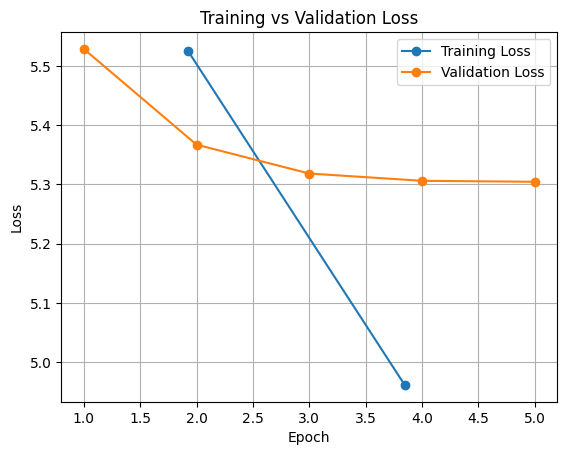

In [ ]:
# plot training vs val loss
plt.figure()

plt.plot(train_epochs, train_loss, marker='o', label="Training Loss")
plt.plot(val_epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate Finetuned Model

In [ ]:
# evaluate finetuned model
results = trainer_p2.evaluate()
results

{'eval_loss': 5.306066989898682,
 'eval_pos_accuracy': 0.7481743086316294,
 'eval_pos_f1_macro': 0.5846935346134644,
 'eval_pos_f1_weighted': 0.7365758616931735,
 'eval_runtime': 5.7171,
 'eval_samples_per_second': 310.996,
 'eval_steps_per_second': 9.795,
 'epoch': 5.0}

### Save Model

In [ ]:
model_multi.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser_multihead")
tokenizer.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser_multihead")
trainer_p2.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ltihead/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...ltihead/model.safetensors:   7%|7         | 31.9MB /  452MB            

CommitInfo(commit_url='https://huggingface.co/amysp/latin-morphological-analyser-multihead/commit/6721a67b22b69e44ef32fe034e6c780df5204c40', commit_message='End of training', commit_description='', oid='6721a67b22b69e44ef32fe034e6c780df5204c40', pr_url=None, repo_url=RepoUrl('https://huggingface.co/amysp/latin-morphological-analyser-multihead', endpoint='https://huggingface.co', repo_type='model', repo_id='amysp/latin-morphological-analyser-multihead'), pr_revision=None, pr_num=None)

## **Evaluation**

In [ ]:
# load final model and tokenizer
MODEL_PATH = "/content/drive/MyDrive/FYP/morphological_analyser_multihead"

# model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH).to(device)
# tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

# trainer = Trainer(
#     model=model,
#     compute_metrics=compute_metrics
# )

In [ ]:
# evaluate model on test set
# trainer.evaluate(test_dataset)

In [ ]:
def predict_sentence(sentence_words, model, tokenizer, device,
                     id2label_all, pos_mask_tensor):
    """
    Given a list of Latin words, return a list of dicts — one per word —
    with the predicted POS and all applicable morphological features.

    Features inapplicable for the predicted POS are returned as "—".
    """
    model.eval()
    words_lower = [w.lower() for w in sentence_words]

    encoding = tokenizer(
        words_lower,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(device)

    word_ids = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        output = model(**encoding)

    pos_logits     = output.logits[0]           # (seq_len, num_pos)
    feature_logits = output.hidden_states[0]    # dict feat → (B, T, num_labels)
    pred_pos_ids   = pos_logits.argmax(dim=-1)  # (seq_len,)

    results, seen = [], set()
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen:
            continue
        seen.add(word_id)

        pos_idx = pred_pos_ids[token_idx].item()
        pos_str = id2label_all["pos"][pos_idx]
        result  = {"word": sentence_words[word_id], "pos": pos_str}

        for feat_idx, feat in enumerate(FEATURE_ORDER):
            if pos_mask_tensor[pos_idx, feat_idx].item():
                # Corrected line: Access the batch dimension (index 0) first
                pred_idx      = feature_logits[feat][0, token_idx].argmax().item()
                result[feat]  = id2label_all[feat][pred_idx]
            else:
                result[feat] = "—"

        results.append(result)
    return results

In [ ]:
# Example:
words = "in principio erat verbum".split()
for r in predict_sentence(words, model_multi, tokenizer, device,
                           id2label_all, pos_mask_tensor):
    print(r)

{'word': 'in', 'pos': 'R-', 'person': '—', 'number': '—', 'tense': '—', 'mood': '—', 'voice': '—', 'gender': '—', 'case': '—', 'degree': '—'}
{'word': 'principio', 'pos': 'Nb', 'person': '—', 'number': 'Sing', 'tense': '—', 'mood': '—', 'voice': '—', 'gender': 'Masc', 'case': 'Abl', 'degree': '—'}
{'word': 'erat', 'pos': 'V-', 'person': '3', 'number': 'Sing', 'tense': 'Imp', 'mood': 'Ind', 'voice': 'Act', 'gender': '—', 'case': '—', 'degree': '—'}
{'word': 'verbum', 'pos': 'Nb', 'person': '—', 'number': 'Sing', 'tense': '—', 'mood': '—', 'voice': '—', 'gender': 'Masc', 'case': 'Nom', 'degree': '—'}


In [ ]:
def evaluate_all_features(model, dataset, tokenizer, device,
                           label2id_all, id2label_all, pos_mask_tensor,
                           batch_size=32):
    """
    Runs inference over the full dataset and produces a classification
    report for every morphological feature separately.
    """
    from torch.utils.data import DataLoader

    model.eval()

    # We need to run our own DataLoader since Trainer only returns pos_logits
    feat_true = {feat: [] for feat in ALL_FEATS}
    feat_pred = {feat: [] for feat in ALL_FEATS}

    loader = DataLoader(
        dataset.with_format("torch"),
        batch_size=batch_size,
        collate_fn=data_collator_multi,
    )

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            output = model(
                input_ids      = batch["input_ids"],
                attention_mask = batch["attention_mask"],
            )

        pos_logits     = output.logits                 # (B, T, num_pos)
        feature_logits = output.hidden_states[0]       # dict feat → (B, T, num_labels)
        pred_pos       = pos_logits.argmax(dim=-1)     # (B, T)
        true_pos       = batch["labels_pos"]           # (B, T)

        valid = true_pos != IGNORE_INDEX               # (B, T)

        # Collect POS
        feat_true["pos"].extend(true_pos[valid].cpu().tolist())
        feat_pred["pos"].extend(pred_pos[valid].cpu().tolist())

        # Collect other features
        for feat_idx, feat in enumerate(FEATURE_ORDER):
            true_feat = batch[f"labels_{feat}"]        # (B, T)

            # Applicable = valid token AND feature is active for its true POS
            pos_clamp   = true_pos.clone()
            pos_clamp[~valid] = 0
            applicable  = pos_mask_tensor[pos_clamp, feat_idx] & valid

            if applicable.any():
                pred_feat = feature_logits[feat].argmax(dim=-1)
                feat_true[feat].extend(true_feat[applicable].cpu().tolist())
                feat_pred[feat].extend(pred_feat[applicable].cpu().tolist())

    # Print reports
    for feat in ALL_FEATS:
        if not feat_true[feat]:
            continue
        num_labels  = len(id2label_all[feat])
        print(f"\n{'='*50}")
        print(f"Feature: {feat.upper()}")
        print(f"{'='*50}")
        print(classification_report(
            feat_true[feat],
            feat_pred[feat],
            labels      = list(range(num_labels)),
            target_names= [id2label_all[feat][i] for i in range(num_labels)],
            zero_division= 0,
        ))

In [ ]:
# Run evaluation:
evaluate_all_features(model_multi, test_ds, tokenizer, device,
                      label2id_all, id2label_all, pos_mask_tensor)


Feature: POS
              precision    recall  f1-score   support

          A-       0.78      0.25      0.38       671
          C-       0.97      0.98      0.97      1335
          Df       0.85      0.71      0.78      1472
          Dq       0.81      0.18      0.29        74
          Du       0.79      0.58      0.67        66
          F-       0.00      0.00      0.00         0
          G-       0.93      0.86      0.89       517
          I-       0.80      0.22      0.34        74
          Ma       0.94      0.42      0.59       158
          Mo       1.00      0.20      0.33        35
          Nb       0.57      0.77      0.66      3159
          Ne       0.62      0.25      0.35       629
          Pc       0.00      0.00      0.00         1
          Pd       0.95      0.59      0.73       500
          Pi       0.87      0.80      0.83        90
          Pk       1.00      0.98      0.99        42
          Pp       0.95      0.83      0.89      1101
          Pr 